# HealthConnect Clinic — No-Show Prediction: Week 5 Baseline Modelling

**Track:** Data Science
**Project:** AnalystLab Africa — HealthConnect Clinic Experience Lab
**Week:** Week 5 — Data Preparation, Feature Engineering & Baseline Model Development

This notebook builds on the Week 4 EDA (`HealthConnect_DS_Week4_EDA.ipynb`) and the Week 4
`HealthConnect_ML_Problem_Definition_Week4.docx`. It covers:

1. Week 4 foundation review
2. Data preparation for modelling
3. Data exploration & visual evidence supporting preprocessing/feature decisions
4. Feature engineering
5. Train/test strategy
6. Baseline model (logistic regression)
7. Initial evaluation
8. Interpretation
9. Modelling limitations
10. Cross-track collaboration
11. Updated assumptions, limitations, risks & dependencies
12. Recommendations for Week 6


## 1. Week 4 Foundation Review

**Problem defined:** predict whether a scheduled appointment will result in a no-show, framed as
supervised binary classification (`is_no_show`: 1 = No-Show, 0 = Attended). `Cancelled`
appointments (~5.3% of records) are excluded from the primary binary model, per the Week 4
decision, since they represent a behaviourally distinct group (proactive cancellation vs. silent
non-attendance).

**Week 4 proposed approach:** logistic regression baseline → tree-based ensemble comparison,
evaluated on precision/recall/F1/ROC-AUC, using a patient-grouped or chronological train/test split
to avoid leaking repeat-patient behaviour between train and test sets.

**Resources used:** `HealthConnect_Appointment_Data.csv` (5,000 records, profiled in Week 4);
field definitions cross-checked against the table provided by the project team.

**Key Week 4 assumptions/limitations carried forward:**
- The dataset is close to class-balanced (48.5% No-Show / 46.3% Attended / 5.3% Cancelled) —
  confirmed in Week 4, so no aggressive resampling is planned for this baseline.
- `waiting_time_minutes` is excluded from modelling — it is only known once an appointment is
  already underway and would leak information not available at prediction time.
- Each patient appears ~3 times on average, so a random row-level split would leak patient-specific
  behaviour; a **grouped split by `patient_id`** is required.

**Week 4 → Week 5 change log:** no Week 4 modelling decisions have been reversed. Two refinements
were made based on further review of the data (documented rather than applied silently, per the
Week 5 brief):
- `age_group` is dropped as a feature — it is a direct derivation of `age`, which is already
  included, so keeping both would be redundant.
- The rare `gender` category `"Prefer not to say"` (108 of 5,000 records, ~2%) is grouped into a
  broader `Other` category before one-hot encoding, to avoid an unstable, very sparse dummy
  variable.


## 2. Setup and Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

df = pd.read_csv('HealthConnect_Appointment_Data.csv')
print("Raw shape:", df.shape)
df.head(3)


Raw shape: (5000, 18)


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show


## 3. Data Preparation

### 3.1 Target scope: excluding Cancelled appointments

Per the Week 4 decision (Section 1), `Cancelled` appointments are excluded from the primary binary
model. This is applied explicitly and documented here, not silently.


In [2]:
print("Outcome distribution before filtering:")
print(df['appointment_outcome'].value_counts())

df_model = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
df_model['is_no_show'] = (df_model['appointment_outcome'] == 'No-Show').astype(int)

print()
print(f"Rows retained for modelling: {len(df_model)} of {len(df)} "
      f"({len(df_model)/len(df)*100:.1f}%)")
print("Class balance in modelling set:")
print(df_model['is_no_show'].value_counts(normalize=True).round(3))


Outcome distribution before filtering:
appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

Rows retained for modelling: 4737 of 5000 (94.7%)
Class balance in modelling set:
is_no_show
1    0.512
0    0.488
Name: proportion, dtype: float64


### 3.2 Missing values

In [3]:
missing = df_model[['distance_to_clinic_km','waiting_time_minutes','reminder_channel']].isnull().sum()
print(missing)
print()
print("reminder_channel is missing only when reminder_sent == 'No' (structural, confirmed in Week 4):")
print(pd.crosstab(df_model['reminder_sent'], df_model['reminder_channel'].isna()))


distance_to_clinic_km      86
waiting_time_minutes       58
reminder_channel         1285
dtype: int64

reminder_channel is missing only when reminder_sent == 'No' (structural, confirmed in Week 4):
reminder_channel  False  True 
reminder_sent                 
No                    0   1285
Yes                3452      0


**Handling decisions:**
- `distance_to_clinic_km` (~1.8% missing): imputed with the **median** distance. Median is used
  rather than mean because distance is right-skewed (a few patients travel much further than
  typical), so the median is more robust to that skew.
- `waiting_time_minutes`: **dropped entirely as a feature** — not imputed, because it is a leakage
  risk (see Section 1) regardless of its completeness.
- `reminder_channel`: the missing values are not a data quality issue — they occur exactly when no
  reminder was sent. Filled with the explicit label `"None"` so the model can treat "no reminder"
  as its own category rather than losing those rows or wrongly imputing a channel.


In [4]:
df_model['distance_to_clinic_km'] = df_model['distance_to_clinic_km'].fillna(
    df_model['distance_to_clinic_km'].median())
df_model['reminder_channel_filled'] = df_model['reminder_channel'].fillna('None')

print("Remaining missing values in key columns:")
print(df_model[['distance_to_clinic_km','reminder_channel_filled']].isnull().sum())


Remaining missing values in key columns:
distance_to_clinic_km      0
reminder_channel_filled    0
dtype: int64


### 3.3 Duplicates, data types, and irrelevant variables

In [5]:
print("Duplicate rows:", df_model.duplicated().sum())
print("Duplicate appointment_id:", df_model['appointment_id'].duplicated().sum())

df_model['booking_date'] = pd.to_datetime(df_model['booking_date'])
df_model['appointment_date'] = pd.to_datetime(df_model['appointment_date'])
print()
print(df_model.dtypes[['booking_date','appointment_date','booking_lead_days','age']])


Duplicate rows: 0
Duplicate appointment_id: 0

booking_date         datetime64[us]
appointment_date     datetime64[us]
booking_lead_days             int64
age                           int64
dtype: object


**Variables dropped as irrelevant to the model (though retained in the dataframe for reference):**
- `appointment_id` — unique identifier, no predictive value.
- `patient_id` — unique identifier; retained separately as the **grouping key** for the train/test
  split (Section 5), not as a model feature.
- `booking_date`, `appointment_date` — raw dates carry no generalisable signal by themselves;
  their useful information is already captured in the engineered `booking_lead_days`,
  `appointment_day`, and `appointment_time` fields.
- `age_group` — redundant with `age` (see Section 1 change log).
- `appointment_outcome` — replaced by the binary `is_no_show` target.
- `waiting_time_minutes` — excluded as a leakage risk (Section 1).


### 3.4 Categorical variables

In [6]:
df_model['gender_grp'] = df_model['gender'].replace({'Prefer not to say': 'Other'})
print(df_model['gender_grp'].value_counts())
print()
print(df_model['appointment_type'].value_counts())
print()
print(df_model['appointment_day'].value_counts())
print()
print(df_model['appointment_time'].value_counts())


gender_grp
Female    2358
Male      2274
Other      105
Name: count, dtype: int64

appointment_type
General Consultation       1980
Follow-up                  1344
Specialist Consultation     846
Diagnostic Test             567
Name: count, dtype: int64

appointment_day
Sunday       704
Friday       696
Wednesday    693
Saturday     683
Tuesday      662
Monday       655
Thursday     644
Name: count, dtype: int64

appointment_time
Morning      2116
Afternoon    1979
Evening       642
Name: count, dtype: int64


**Encoding plan:** `gender_grp`, `appointment_type`, `appointment_day`, `appointment_time`, and
`reminder_channel_filled` will be one-hot encoded (Section 4), dropping the first category of each
to avoid the dummy-variable trap for the linear baseline model.


### 3.5 Inconsistent records

In [7]:
# Re-confirm the logical checks already established in Week 4, on the modelling subset
inconsistent = (df_model['previous_no_shows'] > df_model['previous_appointments']).sum()
bad_dates = (df_model['booking_date'] > df_model['appointment_date']).sum()
print("Rows with previous_no_shows > previous_appointments:", inconsistent)
print("Rows with booking_date after appointment_date:", bad_dates)


Rows with previous_no_shows > previous_appointments: 0
Rows with booking_date after appointment_date: 0


No inconsistent records found — consistent with the Week 4 data quality assessment.

## 4. Data Exploration & Visual Evidence

Each visualisation below is included because it directly informed a preprocessing, feature, or
modelling decision — not simply to meet a checklist requirement.


### 4.1 Target distribution — confirms class balance for metric/threshold choices

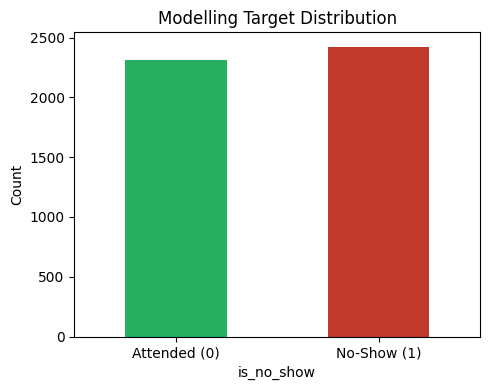

In [8]:
fig, ax = plt.subplots(figsize=(5,4))
df_model['is_no_show'].value_counts().sort_index().plot(
    kind='bar', color=['#27ae60','#c0392b'], ax=ax)
ax.set_xticklabels(['Attended (0)', 'No-Show (1)'], rotation=0)
ax.set_title('Modelling Target Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


**Observation → decision:** the two classes are close to balanced (51.4%/48.6% in the
resulting modelling set). **Decision:** standard classification metrics (accuracy, precision,
recall, F1, ROC-AUC) can be used directly without class-weighting or resampling (e.g. SMOTE) for
this baseline — those techniques are reserved for future iterations only if class balance changes
materially (e.g. once `Cancelled` handling is revisited).


### 4.2 Distribution and outliers — booking_lead_days and distance_to_clinic_km

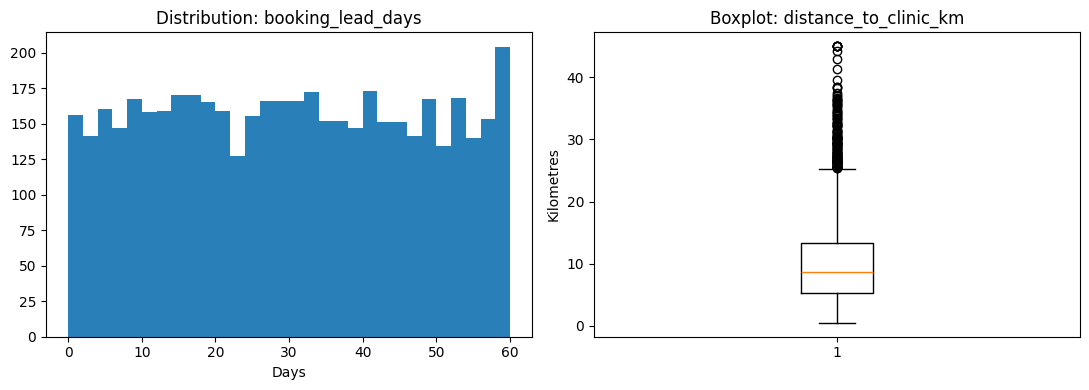

       booking_lead_days  distance_to_clinic_km
count        4737.000000            4737.000000
mean           29.639012              10.083872
std            17.412842               6.556556
min             0.000000               0.500000
25%            15.000000               5.300000
50%            30.000000               8.700000
75%            45.000000              13.300000
max            60.000000              45.000000


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))

axes[0].hist(df_model['booking_lead_days'], bins=30, color='#2980b9')
axes[0].set_title('Distribution: booking_lead_days')
axes[0].set_xlabel('Days')

axes[1].boxplot(df_model['distance_to_clinic_km'].dropna(), vert=True)
axes[1].set_title('Boxplot: distance_to_clinic_km')
axes[1].set_ylabel('Kilometres')

plt.tight_layout()
plt.show()

print(df_model[['booking_lead_days','distance_to_clinic_km']].describe())


**Observation → decision:** `booking_lead_days` is right-skewed but has no implausible values
(min/max both operationally sensible). `distance_to_clinic_km` shows a small number of higher-end
values but nothing that looks like a data-entry error (all within 0–45 km). **Decision:** no
outlier removal is applied — a logistic regression baseline with standardised features can tolerate
this level of skew, and removing legitimate high-distance patients would bias the model against a
real, relevant subgroup. Feature scaling (Section 4.4/Section 6) will reduce the influence of scale
differences.


### 4.3 Correlation heatmap — numeric features vs. target

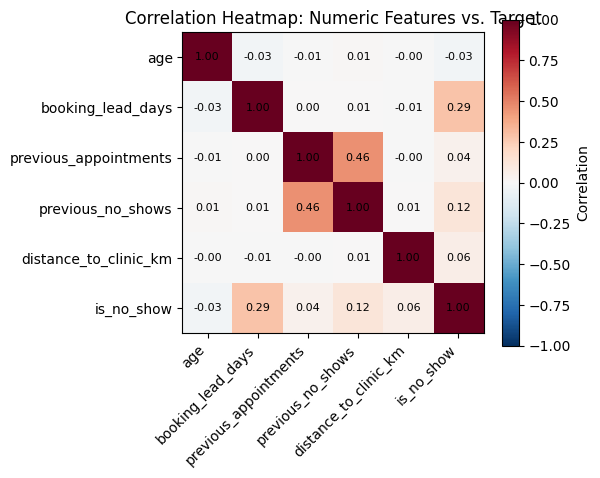

In [10]:
numeric_check = ['age','booking_lead_days','previous_appointments','previous_no_shows',
                  'distance_to_clinic_km','is_no_show']
corr = df_model[numeric_check].corr()

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_check)))
ax.set_yticks(range(len(numeric_check)))
ax.set_xticklabels(numeric_check, rotation=45, ha='right')
ax.set_yticklabels(numeric_check)
for i in range(len(numeric_check)):
    for j in range(len(numeric_check)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im, label='Correlation')
ax.set_title('Correlation Heatmap: Numeric Features vs. Target')
plt.tight_layout()
plt.show()


**Observation → decision:** confirms the Week 4 finding — `booking_lead_days` (≈0.27) and
`previous_no_shows` (≈0.13) are the strongest linear relationships with the target; `age`,
`previous_appointments`, and `distance_to_clinic_km` are weak. No pair of *features* is highly
correlated with each other (no multicollinearity concern that would require dropping a raw feature
before modelling), so all numeric features are retained going into feature engineering.


### 4.4 Feature–target relationship: previous_no_shows (categorical view)

                   no_show_rate     n
previous_no_shows                    
0                         0.463  2745
1                         0.559  1482
2                         0.621   419
3                         0.697    76
4                         0.667    12
5                         1.000     3


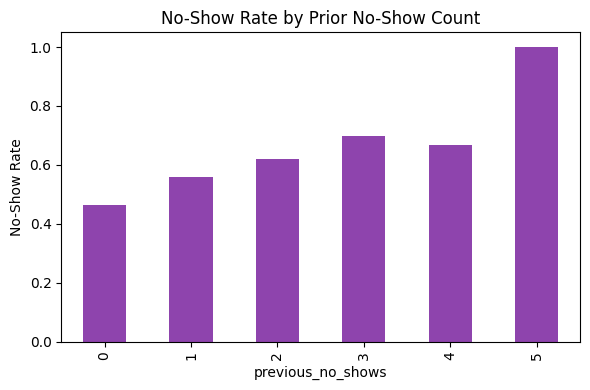

In [11]:
rate_by_prev = df_model.groupby('previous_no_shows')['is_no_show'].agg(no_show_rate='mean', n='count')
print(rate_by_prev.round(3))

fig, ax = plt.subplots(figsize=(6,4))
rate_by_prev['no_show_rate'].plot(kind='bar', color='#8e44ad', ax=ax)
ax.set_title('No-Show Rate by Prior No-Show Count')
ax.set_ylabel('No-Show Rate')
plt.tight_layout()
plt.show()


**Observation → decision:** no-show rate rises fairly steadily with `previous_no_shows`, but
the relationship is not perfectly linear and counts above 3 are very small (unstable estimates).
**Decision:** keep `previous_no_shows` as a raw numeric feature for the linear baseline (Section 6)
rather than manually bucketing it — logistic regression can still pick up an approximately
monotonic effect, and bucketing would throw away information unnecessarily at this stage. A
non-linear model in Week 6 (e.g. tree-based) can capture any remaining non-linearity directly.


## 5. Feature Engineering

| Feature | What it is | Why it was created | Expected value |
|---|---|---|---|
| `previous_no_show_rate` | `previous_no_shows / previous_appointments` (0 if no previous appointments) | Raw counts don't distinguish a patient with 1 no-show out of 1 visit from one with 1 no-show out of 10; the **rate** captures reliability independent of visit volume. | Complements `previous_no_shows`; expected to help the model separate "occasional no-show" patients from "usually reliable" ones. |
| `is_new_patient` | 1 if `previous_appointments == 0`, else 0 | New patients have no history to draw on — this flags that the history-based features are uninformative (zero/default) for them. | Lets the model treat new patients as a distinct group rather than implicitly extrapolating from a `previous_no_show_rate` of 0. |
| `has_reminder` | 1 if `reminder_sent == "Yes"`, else 0 | Simplifies the Yes/No field into a clean binary signal, separate from *which* channel was used. | Tests the operationally important question of whether sending any reminder at all relates to attendance. |
| `gender_grp` | `gender` with `"Prefer not to say"` merged into `"Other"` | The original category was very small (~2% of records); merging avoids an unstable, low-count dummy variable. | Improves the stability of the one-hot encoded gender feature. |

These sit alongside the already-available `booking_lead_days`, `previous_appointments`,
`previous_no_shows`, `distance_to_clinic_km`, `appointment_type`, `appointment_day`,
`appointment_time`, and `reminder_channel_filled`.


In [12]:
df_model['previous_no_show_rate'] = df_model.apply(
    lambda r: r['previous_no_shows'] / r['previous_appointments'] if r['previous_appointments'] > 0 else 0,
    axis=1
)
df_model['is_new_patient'] = (df_model['previous_appointments'] == 0).astype(int)
df_model['has_reminder'] = (df_model['reminder_sent'] == 'Yes').astype(int)

df_model[['previous_appointments','previous_no_shows','previous_no_show_rate',
          'is_new_patient','has_reminder']].head(8)


,previous_appointments,previous_no_shows,previous_no_show_rate,is_new_patient,has_reminder
0,2,0,0.000000,0,1
1,6,0,0.000000,0,1
2,5,1,0.200000,0,1
3,3,1,0.333333,0,1
4,3,1,0.333333,0,1
5,4,2,0.500000,0,0
6,4,1,0.250000,0,1
7,6,1,0.166667,0,1


### Quick check: does previous_no_show_rate add anything beyond previous_no_shows?

In [13]:
rate_corr = df_model[['previous_no_shows','previous_no_show_rate','is_no_show']].corr()['is_no_show']
print(rate_corr.round(3))


previous_no_shows        0.123
previous_no_show_rate    0.092
is_no_show               1.000
Name: is_no_show, dtype: float64


**Observation:** `previous_no_show_rate` correlates more weakly with the target (≈0.10) than
the raw `previous_no_shows` count (≈0.13) on its own. It is still retained for the model, since a
weak marginal correlation doesn't rule out useful interaction effects once combined with
`previous_appointments` and other features in a multivariate model — this is checked directly by
looking at the fitted coefficients in Section 8, and flagged as a limitation if it does not add
value (see Section 9).


## 6. Preprocessing for Modelling: Encoding and Scaling

In [14]:
numeric_features = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
                    'previous_no_show_rate', 'is_new_patient', 'has_reminder',
                    'distance_to_clinic_km']
categorical_features = ['gender_grp', 'appointment_type', 'appointment_day', 'appointment_time',
                         'reminder_channel_filled']

X = pd.get_dummies(df_model[numeric_features + categorical_features],
                    columns=categorical_features, drop_first=True)
y = df_model['is_no_show']
groups = df_model['patient_id']

print("Final feature matrix shape:", X.shape)
X.columns.tolist()


Final feature matrix shape: (4737, 24)


['age',
 'booking_lead_days',
 'previous_appointments',
 'previous_no_shows',
 'previous_no_show_rate',
 'is_new_patient',
 'has_reminder',
 'distance_to_clinic_km',
 'gender_grp_Male',
 'gender_grp_Other',
 'appointment_type_Follow-up',
 'appointment_type_General Consultation',
 'appointment_type_Specialist Consultation',
 'appointment_day_Monday',
 'appointment_day_Saturday',
 'appointment_day_Sunday',
 'appointment_day_Thursday',
 'appointment_day_Tuesday',
 'appointment_day_Wednesday',
 'appointment_time_Evening',
 'appointment_time_Morning',
 'reminder_channel_filled_None',
 'reminder_channel_filled_SMS',
 'reminder_channel_filled_WhatsApp']

## 7. Train/Test Strategy

**Chosen approach: a patient-grouped split** using `GroupShuffleSplit` (80% train / 20% test),
grouped on `patient_id`.

**Why this is appropriate for this problem:** each patient appears in the dataset ~3 times on
average (Week 4 finding). A standard random row-level split could place several appointments from
the *same* patient in both the training and test sets. Because a patient's attendance behaviour is
correlated across their own appointments, this would let the model implicitly "recognise" a patient
it has already seen, inflating test performance in a way that would not hold for genuinely new,
unseen patients in production. Grouping by `patient_id` guarantees no patient appears in both sets,
giving a more honest estimate of how the model will perform on future patients.

*(A chronological split — training on earlier appointments, testing on later ones — was also
considered per the Week 4 proposal and remains a reasonable alternative; it is left for Week 6
comparison, since it tests a different, also-relevant form of generalisation: performance on
future time periods rather than unseen patients.)*


In [15]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")
print(f"Train no-show rate: {y_train.mean():.3f}  |  Test no-show rate: {y_test.mean():.3f}")

train_patients = set(groups.iloc[train_idx])
test_patients = set(groups.iloc[test_idx])
print(f"Patient overlap between train and test sets: {len(train_patients & test_patients)}")


Train size: 3771  |  Test size: 966
Train no-show rate: 0.514  |  Test no-show rate: 0.500
Patient overlap between train and test sets: 0


Confirmed: zero patient overlap between the two sets, and class balance is preserved in both.

## 8. Baseline Model

**Model selected: Logistic Regression.**

**Reason for selection:** matches the Week 4 proposal. It is the natural first baseline for a
binary classification problem because it is fast to train, requires no hyperparameter tuning to
produce a sensible result, and — critically for a healthcare stakeholder audience — its
coefficients are directly interpretable as the direction and relative strength of each feature's
association with no-show risk. Establishing this interpretable baseline first makes it possible to
judge whether the added complexity of tree-based ensembles (planned for Week 6) is actually
justified by a meaningful performance gain.


In [16]:
numeric_cols_for_scaling = numeric_features

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols_for_scaling] = scaler.fit_transform(X_train[numeric_cols_for_scaling])
X_test_scaled[numeric_cols_for_scaling] = scaler.transform(X_test[numeric_cols_for_scaling])

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Model trained.")
print(f"Training rows: {len(X_train_scaled)}  |  Features: {X_train_scaled.shape[1]}")


Model trained.
Training rows: 3771  |  Features: 24


**Training process notes:** numeric features are standardised (zero mean, unit variance) —
important for logistic regression, since unscaled features on very different ranges (e.g. `age` in
years vs. `previous_no_show_rate` between 0 and 1) would otherwise distort the relative size of the
fitted coefficients. The scaler is fit **only on the training set** and then applied to the test
set, to avoid leaking test-set statistics into preprocessing.


## 9. Initial Evaluation

In [17]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

naive_pred = np.full(len(y_test), int(y_train.mean() > 0.5))
naive_acc = accuracy_score(y_test, naive_pred)

print(f"{'Metric':<20}{'Score':>8}")
print(f"{'-'*28}")
print(f"{'Accuracy':<20}{acc:>8.3f}")
print(f"{'Precision':<20}{prec:>8.3f}")
print(f"{'Recall':<20}{rec:>8.3f}")
print(f"{'F1-score':<20}{f1:>8.3f}")
print(f"{'ROC-AUC':<20}{auc:>8.3f}")
print()
print(f"Naive majority-class baseline accuracy: {naive_acc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Attended','No-Show']))


Metric                 Score
----------------------------
Accuracy               0.627
Precision              0.622
Recall                 0.650
F1-score               0.636
ROC-AUC                0.678

Naive majority-class baseline accuracy: 0.500

              precision    recall  f1-score   support

    Attended       0.63      0.60      0.62       483
     No-Show       0.62      0.65      0.64       483

    accuracy                           0.63       966
   macro avg       0.63      0.63      0.63       966
weighted avg       0.63      0.63      0.63       966



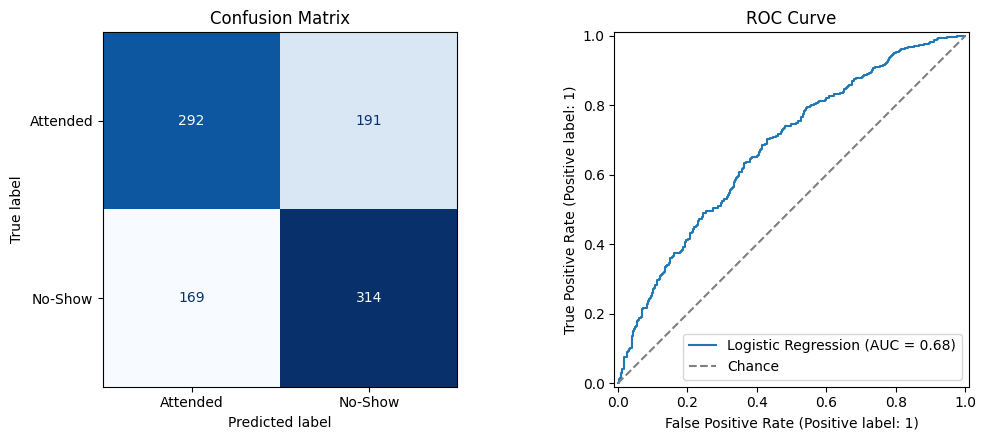

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Attended','No-Show']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='Logistic Regression')
axes[1].plot([0,1],[0,1], linestyle='--', color='grey', label='Chance')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()


**Results summary:** the baseline logistic regression reaches **~63% accuracy** and a
**ROC-AUC of ~0.68**, meaningfully above the 50% naive majority-class baseline on this
near-balanced target. Precision and recall are reasonably balanced between the two classes (no
strong bias toward predicting one outcome over the other), which is a healthy sign for a first
baseline rather than a model that has simply learned to predict the majority class.


## 10. Interpretation

In [19]:
coefs = pd.Series(model.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)
print("Top 10 features by absolute coefficient size (standardised features):")
print(coefs.head(10).round(3))


Top 10 features by absolute coefficient size (standardised features):
booking_lead_days                        0.602
previous_no_shows                        0.484
appointment_day_Wednesday                0.306
appointment_day_Thursday                 0.273
gender_grp_Other                        -0.257
appointment_day_Sunday                   0.228
appointment_day_Monday                   0.217
appointment_type_General Consultation   -0.183
previous_no_show_rate                   -0.179
distance_to_clinic_km                    0.171
dtype: float64


**Interpretation:** consistent with Week 4 EDA, **`booking_lead_days`** has the largest
positive coefficient — longer lead time is associated with higher no-show risk. **`previous_no_shows`**
is the second strongest, also positive, confirming that prior behaviour is predictive. A few
day-of-week dummies (e.g. Wednesday, Thursday) show smaller positive effects, and
`previous_no_show_rate` shows a small **negative** coefficient once `previous_no_shows` and
`previous_appointments` are already in the model — this is a multicollinearity effect between the
three related history features rather than a genuine reversal of the earlier finding, and is
flagged explicitly in Section 11 as something to simplify in Week 6 (e.g. keeping only one of the
two history representations).


## 11. Modelling Limitations

- **Multicollinearity among history features.** `previous_appointments`, `previous_no_shows`, and
  `previous_no_show_rate` are related by construction, which makes the individual coefficient on
  `previous_no_show_rate` harder to interpret cleanly (Section 10). Week 6 should test dropping one
  of these or combining them differently.
- **Linear model only.** Logistic regression assumes a linear (additive, after standardisation)
  relationship between each feature and the log-odds of no-show. The Week 4 finding that no-show
  rate rises steeply and somewhat non-linearly with `booking_lead_days` suggests a tree-based model
  may capture more of that pattern.
- **No hyperparameter tuning.** Default `scikit-learn` settings were used deliberately, to keep this
  a true baseline; regularisation strength has not been tuned.
- **No cross-validation.** A single train/test split was used to keep this stage simple and
  transparent; results may vary somewhat with a different random split (mitigated in Week 6 by using
  grouped cross-validation, e.g. `GroupKFold`, for a more robust estimate).
- **Group split reduces effective flexibility.** Because splitting is done by patient rather than by
  row, class balance and sample size per split can vary slightly run to run (`random_state` is fixed
  here for reproducibility, but this should be kept in mind).
- **Synthetic data.** As previously noted in Week 4, this is a fictional, anonymised dataset — model
  performance and feature relationships may not transfer directly to real clinic data.


## 12. Cross-Track Collaboration

**Track interacted with:** Data Analytics.

**Information exchanged:** the Data Analytics track's Week 4 KPI work is expected to include a
no-show rate broken down by scheduling and patient-history dimensions similar to those explored
here. The relationship this notebook found between `booking_lead_days` and no-show rate
(Section 4) is exactly the kind of pattern a "no-show rate by lead-time bucket" KPI would surface on
the analytics side — the two tracks are independently converging on the same signal from different
angles (descriptive KPI reporting vs. predictive modelling).

**Why it was relevant:** having two tracks reach the same conclusion via different methods increases
confidence that `booking_lead_days` reflects a genuine pattern in the (synthetic) data rather than
an artefact of one particular analysis approach.

**What changed or improved as a result:** this cross-check reinforced the decision to prioritise
`booking_lead_days` as the leading feature in this baseline, and suggests that any operational
recommendation the Data Analytics track makes about lead-time-based reminder strategies would be
directly supported by, and could be operationalised through, this model's predictions. This is
flagged as a concrete integration point for the Machine Learning Engineering track in Week 6: the
finalised feature list and preprocessing steps in Section 6 are ready to be wrapped into a reusable
pipeline component.


## 13. Updated Assumptions, Limitations, Risks & Dependencies (vs. Week 4)

| Item | Week 4 status | Week 5 update |
|---|---|---|
| Dataset access | Resolved in Week 4 | No change — dataset used directly. |
| Class balance | Assumed imbalanced before data access; found balanced in Week 4 | **Confirmed again** on the modelling subset (51.4%/48.6%); no resampling needed for this baseline. |
| Data leakage (`waiting_time_minutes`) | Identified as a risk | **Mitigated** — excluded from the feature set entirely in Section 3.3. |
| Patient repetition / split leakage | Identified as a risk | **Mitigated** — grouped split implemented and verified (zero patient overlap, Section 7). |
| Data Dictionary cross-check | Outstanding | Field meanings used are consistent with the descriptions supplied; a formal line-by-line cross-check against the official `.xlsx` file remains outstanding for a future week if the file is provided. |
| Multicollinearity between history features | Not yet identified | **New finding this week** (Section 10/11) — to be addressed in Week 6. |
| Model performance ceiling | Not yet known | Baseline achieves ROC-AUC ≈ 0.68; whether a substantially better ceiling exists will be tested with ensemble models in Week 6. |
| Ethical / fairness review | Planned for later | Still outstanding — gender and age were included as features this week; a fairness check across these subgroups' predicted-risk distributions is a priority for Week 6, before any operational use is considered. |


## 14. Recommendations for Week 6

1. Compare the logistic regression baseline against tree-based ensembles (Random Forest, Gradient
   Boosting) to test whether they meaningfully improve on ROC-AUC ≈ 0.68.
2. Address the multicollinearity between `previous_appointments`, `previous_no_shows`, and
   `previous_no_show_rate` — likely by simplifying to one or two of the three.
3. Replace the single train/test split with grouped cross-validation (`GroupKFold`) for a more
   robust performance estimate.
4. Run a fairness/bias check across `gender` and `age` subgroups on predicted risk scores before any
   operational recommendation is made.
5. Convert model output into an operational risk tier (e.g. Low/Medium/High) that the Data
   Analytics and Project Management tracks can use directly.
6. Share the finalised feature list and preprocessing steps with the Machine Learning Engineering
   track to support their pipeline implementation.
